In [1]:
import os
from pathlib import Path
from typing import Tuple, List, Dict
import numpy as np
import re


class UIPRMDLoader:

    def __init__(self):
        """
        Args:
            data_root: Path to UI-PRMD root directory
        """
        self.data_root = Path("D:/Programming/UI-PRMD")
        self.samples: List[str] = []
        self.labels: List[int] = []
        self.exercise_ids: List[int] = []
        self.subject_ids: List[int] = []
        self.metadata: List[Dict] = []
        self.num_joints: int = None
        self.target_features: int = None

    def _parse_filename(self, filename: str) -> Tuple[int, int, int]:
        """
        Parse E<ex>_S<sub>_R<rep>_[C|I] format.
        Returns: (exercise_id, subject_id, rep_id)
        """
        # Legacy format: E<exercise>_S<subject>_R<rep>
        match = re.match(r"E(\d+)_S(\d+)_R(\d+)", filename, flags=re.IGNORECASE)
        if match:
            # Keep 0-based exercise indexing for CLI --exercise argument
            return int(match.group(1)) - 1, int(match.group(2)), int(match.group(3))

        # UI-PRMD segmented format: m<movement>_s<subject>_e<rep>_positions(.txt/_inc.txt)
        match = re.match(r"m(\d+)_s(\d+)_e(\d+)_", filename, flags=re.IGNORECASE)
        if match:
            return int(match.group(1)) - 1, int(match.group(2)), int(match.group(3))

        # UI-PRMD non-segmented format: m<movement>_s<subject>_positions(.txt/_inc.txt)
        match = re.match(r"m(\d+)_s(\d+)_", filename, flags=re.IGNORECASE)
        if match:
            return int(match.group(1)) - 1, int(match.group(2)), 1

        return None, None, None

    def scan_files(self, exercise_id: int = None):
            """Scan directory for data files."""
            self.samples = []
            self.labels = []
            self.exercise_ids = []
            self.subject_ids = []
            self.metadata = []

            sources = [
                # Official UI-PRMD segmented
                (self.data_root / "Segmented Movements" / "Vicon" / "Positions", 0),
                (self.data_root / "Incorrect Segmented Movements" / "Vicon" / "Positions", 1),
                # Non-segmented
                (self.data_root / "Movements" / "Vicon" / "Positions", 0),
                (self.data_root / "Incorrect Movements" / "Vicon" / "Positions", 1),
                # Legacy CSV format
                (self.data_root / "correct", 0),
                (self.data_root / "incorrect", 1),
            ]
            
            for source_dir, label in sources:
                if not source_dir.exists():
                    continue
                
                pattern = "*.txt" if "Vicon" in str(source_dir) else "*.csv"
                for fpath in source_dir.glob(pattern):
                    eid, sid, rid = self._parse_filename(fpath.name)
                    
                    if eid is None:
                        continue
                    if exercise_id is not None and eid != exercise_id:
                        continue
                    
                    self.samples.append(str(fpath))
                    self.labels.append(label)
                    self.exercise_ids.append(eid)
                    self.subject_ids.append(sid if sid is not None else -1)
                    
                    self.metadata.append({
                        "file": str(fpath),
                        "exercise_id": eid,
                        "subject_id": sid,
                        "rep": rid,
                        "label": label,
                        "label_name": "correct" if label == 0 else "incorrect"
                    })

In [2]:
UIPRMDLoader = UIPRMDLoader()
UIPRMDLoader.scan_files()

In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d

class UIPRMDStudio:
    def __init__(self, root_path):
        self.root = root_path
        # UI-PRMD Vicon 22-joint connections for visualization
        self.skeleton_edges = [
    # --- HEAD ---
    (0, 1), (1, 3), (3, 2), (2, 0),      # Head box: LFHD, RFHD, RBHD, LBHD
    
    # --- TORSO & SPINE ---
    (4, 5), (5, 6), (6, 7),              # C7 -> T10 -> CLAV -> STRN
    (4, 0), (4, 1),                      # Neck to Front Head
    (6, 8),                              # CLAV to RBAK (Back marker)
    
    # --- LEFT ARM ---
    (6, 9), (9, 10), (10, 11), (11, 12), # CLAV -> LSHO -> LUPA -> LELB -> LFRM
    (12, 13), (12, 14), (13, 15), (14, 15), # Wrist/Hand cluster (LWRA, LWRB, LFIN)
    
    # --- RIGHT ARM ---
    (6, 16), (16, 17), (17, 18), (18, 19), # CLAV -> RSHO -> RUPA -> RELB -> RFRM
    (19, 20), (19, 21), (20, 22), (21, 22), # Wrist/Hand cluster (RWRA, RWRB, RFIN)
    
    # --- PELVIS ---
    (7, 23), (7, 24),                    # STRN to LASI/RASI (Hips)
    (23, 25), (24, 26), (25, 26), (23, 24), # Pelvic "bowl": ASIS and PSIS markers
    
    # --- LEFT LEG ---
    (23, 27), (27, 28), (28, 29),        # LASI -> LTHI -> LKNE -> LTIB
    (29, 30), (30, 31), (30, 32), (31, 32), # LANK -> LHEE -> LTOE (Foot)
    
    # --- RIGHT LEG ---
    (24, 33), (33, 34), (34, 35),        # RASI -> RTHI -> RKNE -> RTIB
    (35, 36), (36, 37), (36, 38), (37, 38)  # RANK -> RHEE -> RTOE (Foot)
]

    def _get_files(self):
        """Scans the directory and extracts path, label, and exercise ID."""
        files = []
        search_paths = [
            (os.path.join(self.root, "Segmented Movements", "Vicon", "Positions"), 0),
            (os.path.join(self.root, "Incorrect Segmented Movements", "Vicon", "Positions"), 1)
        ]
        
        for path, label in search_paths:
            if not os.path.exists(path):
                continue
            for f in os.listdir(path):
                if f.endswith('.txt'):
                    # Extract 'm01' or 'E01' from the start of the filename
                    # UI-PRMD files usually look like 'm01_s01_e01_positions.txt'
                    exercise_match = re.match(r'([a-zA-Z]\d+)', f)
                    ex_id = exercise_match.group(1).lower() if exercise_match else "unknown"
                    
                    files.append({
                        'path': os.path.join(path, f), 
                        'name': f, 
                        'label': label,
                        'exercise': ex_id  # THIS WAS MISSING
                    })
        return pd.DataFrame(files)

    def load_sequence(self, file_path, target_len=100):
        try:
            # 1. Added ndmin=2 to prevent 1D array crashes on short files
            data = np.loadtxt(file_path, delimiter=',', ndmin=2)
            
            # 2. Safety check: Ensure we actually have 117 columns
            if data.shape[1] < 117:
                return None
            
            # 3. Reshape to [Frames, Joints, Coordinates]
            # We only take the first 117 columns (39 joints * 3)
            coords = data[:, :117].reshape(-1, 39, 3) 
            
            # 4. Check if we have enough frames to interpolate
            curr_len = coords.shape[0]
            if curr_len < 2:
                return None

            # 5. Centering (Relative to Pelvis)
            # Using joints 0, 23, and 31 as the 'root' anchor
            pelvis_center = (coords[:, 0] + coords[:, 23] + coords[:, 31]) / 3.0
            coords = coords - pelvis_center[:, np.newaxis, :]

            # 6. Temporal Interpolation (Standardize length to 100)
            x_old = np.linspace(0, 1, curr_len)
            x_new = np.linspace(0, 1, target_len)
            
            # Flatten for interpolation: [Frames, 39*3]
            flat_coords = coords.reshape(curr_len, -1)
            f = interp1d(x_old, flat_coords, axis=0, kind='linear')
            
            # Resample and reshape back to [100, 39, 3]
            resampled = f(x_new).reshape(target_len, 39, 3)
            
            return resampled.astype(np.float32) # Standardize to float32 for deep learning
            
        except Exception as e:
            # print(f"Error loading {file_path}: {e}")
            return None

    def visualize_frame(self, sequence, frame_idx=0):
        """Plots a 3D skeleton for a specific frame."""
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        skeleton = sequence[frame_idx]
        
        # Plot joints
        ax.scatter(skeleton[:, 0], skeleton[:, 1], skeleton[:, 2], c='blue', s=20)
        
        # Plot bones (if indices match your version's joints)
        # If your version has 22 joints, indices 0-21. 
        # Note: UI-PRMD column mapping can be tricky; usually 0 is Pelvis/Waist.
        for edge in self.skeleton_edges:
            try:
                joint1 = skeleton[edge[0]]
                joint2 = skeleton[edge[1]]
                ax.plot([joint1[0], joint2[0]], [joint1[1], joint2[1]], [joint1[2], joint2[2]], color='red')
            except IndexError:
                continue

        ax.view_init(elev=20, azim=-90)

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f"Skeleton Visualization - Frame {frame_idx}")
        plt.show()

# --- Execution ---
studio = UIPRMDStudio("D:/Programming/UI-PRMD")
df_files = studio._get_files()

print(f"Total files found: {len(df_files)}")
print(df_files.head())

Total files found: 1980
                                                path  \
0  D:/Programming/UI-PRMD\Segmented Movements\Vic...   
1  D:/Programming/UI-PRMD\Segmented Movements\Vic...   
2  D:/Programming/UI-PRMD\Segmented Movements\Vic...   
3  D:/Programming/UI-PRMD\Segmented Movements\Vic...   
4  D:/Programming/UI-PRMD\Segmented Movements\Vic...   

                        name  label exercise  
0  m01_s01_e01_positions.txt      0      m01  
1  m01_s01_e02_positions.txt      0      m01  
2  m01_s01_e03_positions.txt      0      m01  
3  m01_s01_e04_positions.txt      0      m01  
4  m01_s01_e05_positions.txt      0      m01  


In [4]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


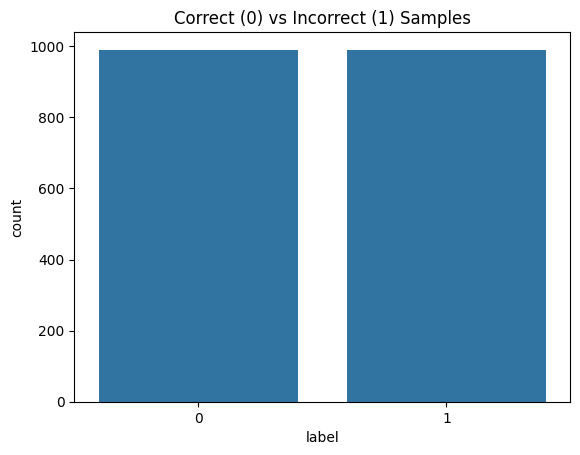

In [ ]:
import seaborn as sns
sns.countplot(data=df_files, x='label')
plt.title("Correct (0) vs Incorrect (1) Samples")
plt.show()

Extracting features for 39 joints from 1980 files...


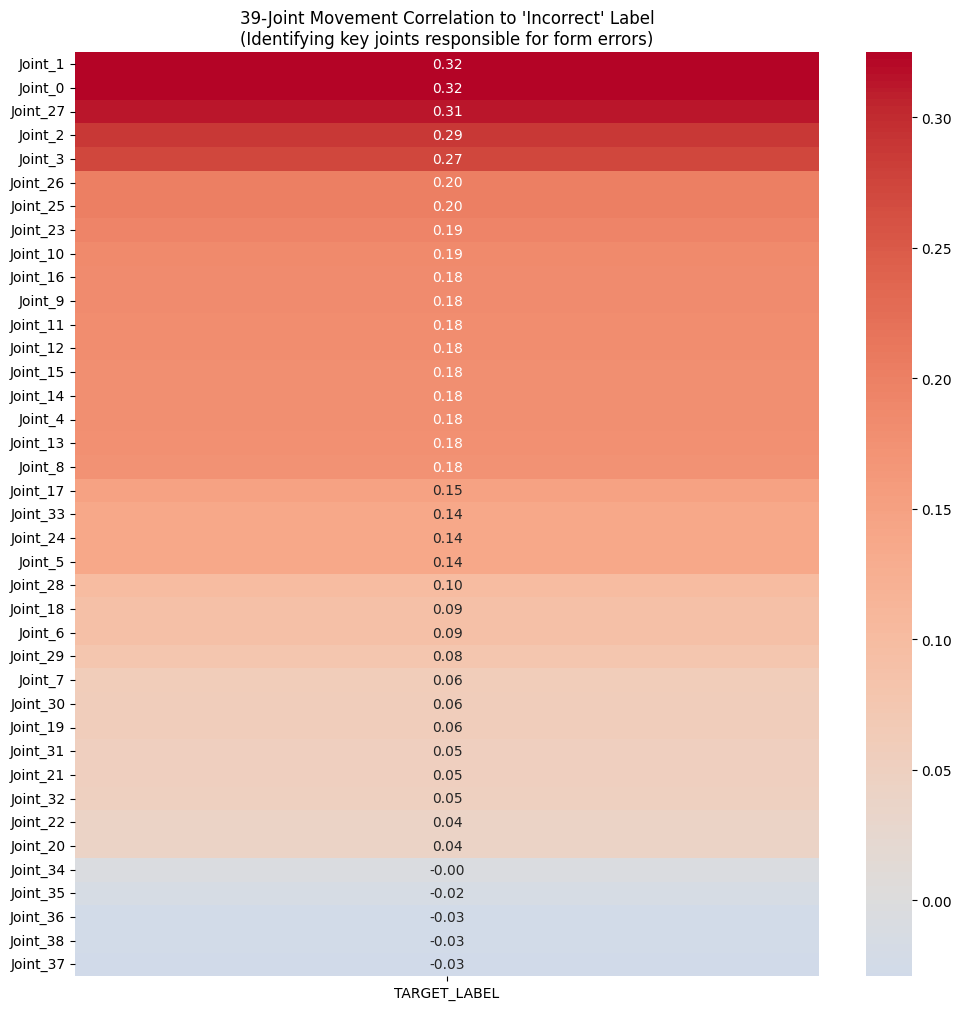

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_joint_label_correlation(studio, df_files):
    features = []
    labels = []
    
    # 39 Joint Names (Vicon Marker Set)
    # If specific names aren't mapped, we use indices for precision
    joint_names = [f"Joint_{i}" for i in range(39)]
    
    # Optional: Mapping key groups for easier reading
    # 0-8: Torso/Head, 9-15: Right Arm, 16-22: Left Arm
    # 23-30: Right Leg, 31-38: Left Leg

    print(f"Extracting features for 39 joints from {len(df_files)} files...")
    
    for _, row in df_files.iterrows():
        # load_sequence now handles 117 columns -> (T, 39, 3)
        seq = studio.load_sequence(row['path'])
        
        if seq is None:
            continue
        
        # Calculate Peak-to-Peak (Range of Motion) per joint
        # ptp on axis 0 gives max-min for each joint's x, y, z
        rom = np.ptp(seq, axis=0) 
        
        # Magnitude of the movement for each of the 39 joints
        magnitude = np.linalg.norm(rom, axis=1) 
        
        features.append(magnitude)
        labels.append(row['label'])

    if not features:
        print("No valid sequences were loaded. Check your file paths and load_sequence logic.")
        return None, None

    # Create DataFrame with 39 columns
    data = np.array(features)
    corr_df = pd.DataFrame(data, columns=joint_names)
    corr_df['TARGET_LABEL'] = labels

    # Calculate Pearson Correlation
    correlation_matrix = corr_df.corr()
    
    # Sort by correlation with label (Correct: 0, Incorrect: 1)
    # Positive values mean: "More movement in this joint = more likely to be incorrect"
    label_corr = correlation_matrix[['TARGET_LABEL']].sort_values(by='TARGET_LABEL', ascending=False)
    
    # Drop the TARGET_LABEL row itself from the correlation display
    label_corr = label_corr.drop('TARGET_LABEL')
    
    return label_corr, correlation_matrix

# Execute
label_corr, full_mtx = compute_joint_label_correlation(studio, df_files)

# Visualize
if label_corr is not None:
    plt.figure(figsize=(12, 12))
    sns.heatmap(label_corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
    plt.title("39-Joint Movement Correlation to 'Incorrect' Label\n(Identifying key joints responsible for form errors)")
    plt.show()

In [ ]:
print(df_files.head())

                                                path  \
0  D:/Programming/UI-PRMD\Segmented Movements\Vic...   
1  D:/Programming/UI-PRMD\Segmented Movements\Vic...   
2  D:/Programming/UI-PRMD\Segmented Movements\Vic...   
3  D:/Programming/UI-PRMD\Segmented Movements\Vic...   
4  D:/Programming/UI-PRMD\Segmented Movements\Vic...   

                        name  label exercise  
0  m01_s01_e01_positions.txt      0      m01  
1  m01_s01_e02_positions.txt      0      m01  
2  m01_s01_e03_positions.txt      0      m01  
3  m01_s01_e04_positions.txt      0      m01  
4  m01_s01_e05_positions.txt      0      m01  


In [5]:
# Filter for just Deep Squats
df_squats = df_files[df_files['exercise'] == 'm01']

# Run the correlation just on this slice
label_corr, full_mtx = compute_joint_label_correlation(studio, df_squats)

# Plot
sns.heatmap(label_corr, annot=True, cmap='RdYlGn_r')
plt.title("Joint Importance for Squat Correctness")

NameError: name 'compute_joint_label_correlation' is not defined

In [6]:
# Connections based on the 22-joint UI-PRMD Vicon mapping
VICON_EDGES = [
    # Spine & Head
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6),
    # Right Arm
    (4, 7), (7, 8), (8, 9), (9, 10),
    # Left Arm
    (4, 11), (11, 12), (12, 13), (13, 14),
    # Right Leg
    (0, 15), (15, 16), (16, 17), (17, 18),
    # Left Leg
    (0, 19), (19, 20), (20, 21)
]

# Updated connections for the 39-joint (117 column) Vicon setup
# Refined 39-Joint (Plug-in Gait) Edge List
# Precise edges based on the provided UI-PRMD Vicon Joint Order
# (Subtracting 1 from your image's ID to match Python 0-indexing)
VICON_39_EDGES = [
    # --- HEAD & SPINE ---
    (0, 2), (1, 3), (0, 1), (2, 3),      # Head box (LFHD, RFHD, LBHD, RBHD)
    (4, 5), (5, 6), (6, 7), (7, 8),      # Spine: C7 -> T10 -> CLAV -> STRN -> RBAK
    (4, 0), (4, 1),                      # Neck to Head
    
    # --- LEFT ARM ---
    (6, 9),                              # Clavicle to Left Shoulder (LSHO)
    (9, 10), (10, 11), (11, 12),         # LSHO -> LUPA -> LELB -> LFRM
    (12, 13), (12, 14), (13, 15), (14, 15), # Wrist/Hand cluster (LWRA, LWRB, LFIN)
    
    # --- RIGHT ARM ---
    (6, 16),                             # Clavicle to Right Shoulder (RSHO)
    (16, 17), (17, 18), (18, 19),        # RSHO -> RUPA -> RELB -> RFRM
    (19, 20), (19, 21), (20, 22), (21, 22), # Wrist/Hand cluster (RWRA, RWRB, RFIN)
    
    # --- LOWER BODY / PELVIS ---
    (7, 23), (7, 24),                    # Sternum to Pelvis ASIS markers
    (23, 25), (24, 26), (25, 26),        # ASIS to PSIS (Pelvic bowl)
    
    # --- LEFT LEG ---
    (23, 27), (27, 28), (28, 29),        # LASI -> LTHI -> LKNE -> LTIB
    (29, 30), (30, 31), (30, 32), (31, 32), # LANK -> LHEE -> LTOE (Foot)
    
    # --- RIGHT LEG ---
    (24, 33), (33, 34), (34, 35),        # RASI -> RTHI -> RKNE -> RTIB
    (35, 36), (36, 37), (36, 38), (37, 38)  # RANK -> RHEE -> RTOE (Foot)
]

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_skeleton_3d(frame_data, edges=VICON_39_EDGES, elev=20, azim=-90):
    """
    frame_data: numpy array of shape (22, 3)
    """
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Plot the Joints (Dots)
    ax.scatter(frame_data[:, 0], frame_data[:, 1], frame_data[:, 2], 
               c='blue', s=50, label='Joints')

    # 2. Plot the Bones (Lines)
    for start, end in edges:
        x = [frame_data[start, 0], frame_data[end, 0]]
        y = [frame_data[start, 1], frame_data[end, 1]]
        z = [frame_data[start, 2], frame_data[end, 2]]
        ax.plot(x, y, z, c='red', linewidth=2)

    # 3. Add Labels for identification
    for i in range(len(frame_data)):
        ax.text(frame_data[i, 0], frame_data[i, 1], frame_data[i, 2], str(i), size=8)

    # Setting limits (adjust based on your mm values, usually around -1000 to 2000)
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_zlabel('Z (mm)')
    ax.set_title("UI-PRMD Skeleton Visualization")
    
    # Equalize aspect ratio so the human isn't squashed
    max_range = np.array([frame_data[:,0].max()-frame_data[:,0].min(), 
                          frame_data[:,1].max()-frame_data[:,1].min(), 
                          frame_data[:,2].max()-frame_data[:,2].min()]).max() / 2.0

    mid_x = (frame_data[:,0].max()+frame_data[:,0].min()) * 0.5
    mid_y = (frame_data[:,1].max()+frame_data[:,1].min()) * 0.5
    mid_z = (frame_data[:,2].max()+frame_data[:,2].min()) * 0.5
    
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    ax.view_init(elev=elev, azim=azim)

    ax.set_xlim3d([-1000, 1000])
    ax.set_ylim3d([-1000, 1000])
    ax.set_zlim3d([-1000, 1000])

    plt.show()

# Usage:
# sample_sequence = studio.load_sequence(df_files.iloc[0]['path'])
# plot_skeleton_3d(sample_sequence[0]) # Plot the first frame

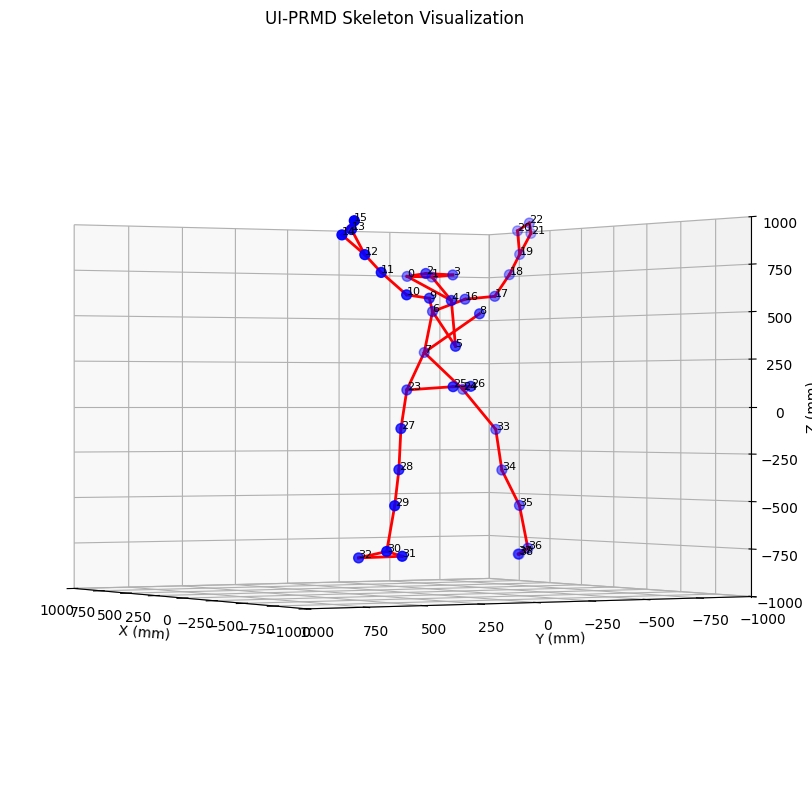

In [9]:
from IPython.display import clear_output
import time

sequence = studio.load_sequence(df_files.iloc[0]['path'])

for i in range(0, 100, 5): # Every 5th frame
    clear_output(wait=True)
    plot_skeleton_3d(sequence[i], edges=VICON_39_EDGES, elev=0, azim=150)
    time.sleep(0.1)

In [ ]:
# This prints the first row of your data
first_row = np.loadtxt(df_files.iloc[0]['path'], delimiter=',')[0]
print(f"Number of columns: {len(first_row)}")

Number of columns: 117


In [ ]:
# Side profile view
studio.visualize_frame(sequence, frame_idx=0, elev=0, azim=0)

# Frontal view
studio.visualize_frame(sequence, frame_idx=0, elev=0, azim=-90)

TypeError: UIPRMDStudio.visualize_frame() got an unexpected keyword argument 'elev'